========== FIRST 5 ROWS ==========

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

========== DATASET INFO ==========

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   tre

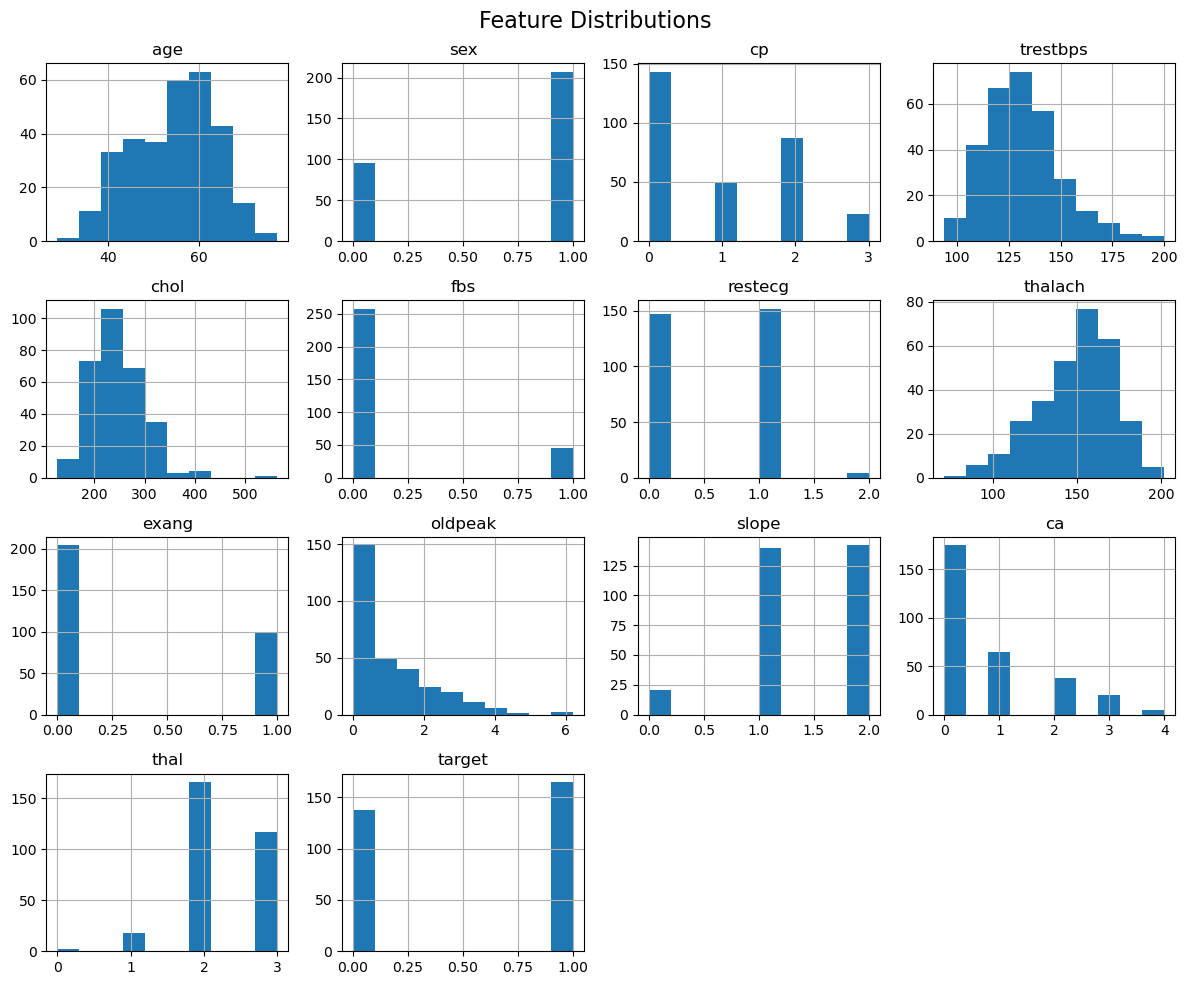


Generating Boxplot...


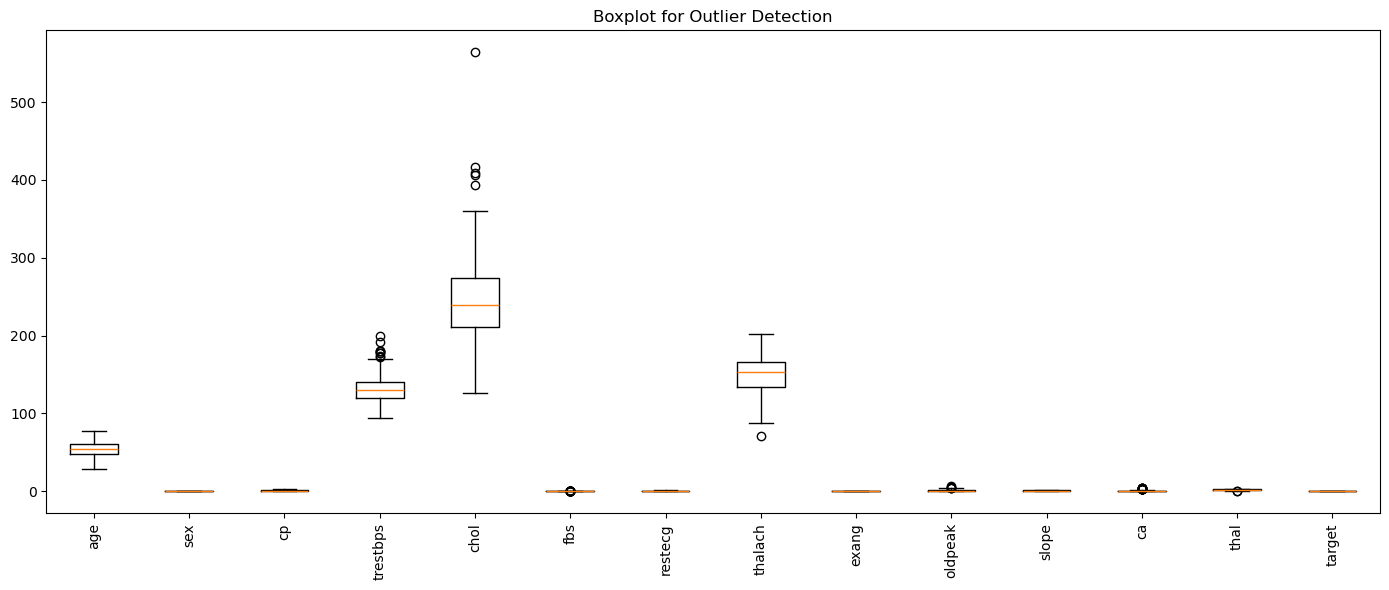


========== CORRELATION MATRIX ==========

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.098447 -0.068653  0.279351  0.213678  0.121308   
sex      -0.098447  1.000000 -0.049353 -0.056769 -0.197912  0.045032   
cp       -0.068653 -0.049353  1.000000  0.047608 -0.076904  0.094444   
trestbps  0.279351 -0.056769  0.047608  1.000000  0.123174  0.177531   
chol      0.213678 -0.197912 -0.076904  0.123174  1.000000  0.013294   
fbs       0.121308  0.045032  0.094444  0.177531  0.013294  1.000000   
restecg  -0.116211 -0.058196  0.044421 -0.114103 -0.151040 -0.084189   
thalach  -0.398522 -0.044020  0.295762 -0.046698 -0.009940 -0.008567   
exang     0.096801  0.141664 -0.394280  0.067616  0.067023  0.025665   
oldpeak   0.210013  0.096093 -0.149230  0.193216  0.053952  0.005747   
slope    -0.168814 -0.030711  0.119717 -0.121475 -0.004038 -0.059894   
ca        0.276326  0.118261 -0.181053  0.101389  0.070511  0.137979   
thal      0.068001  0

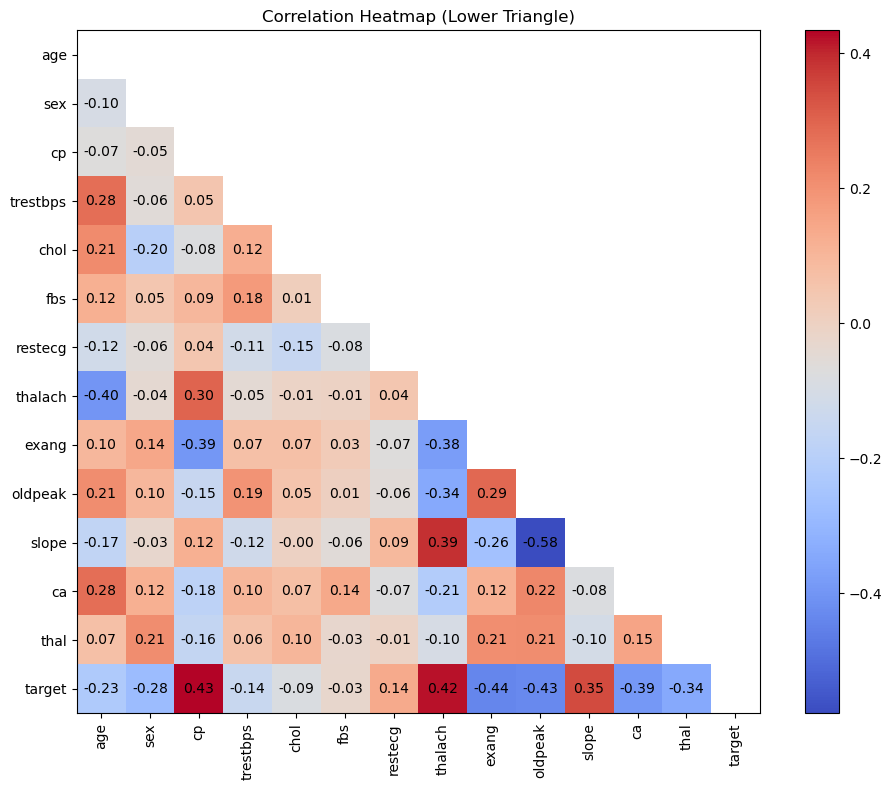


Generating Scatter Matrix...



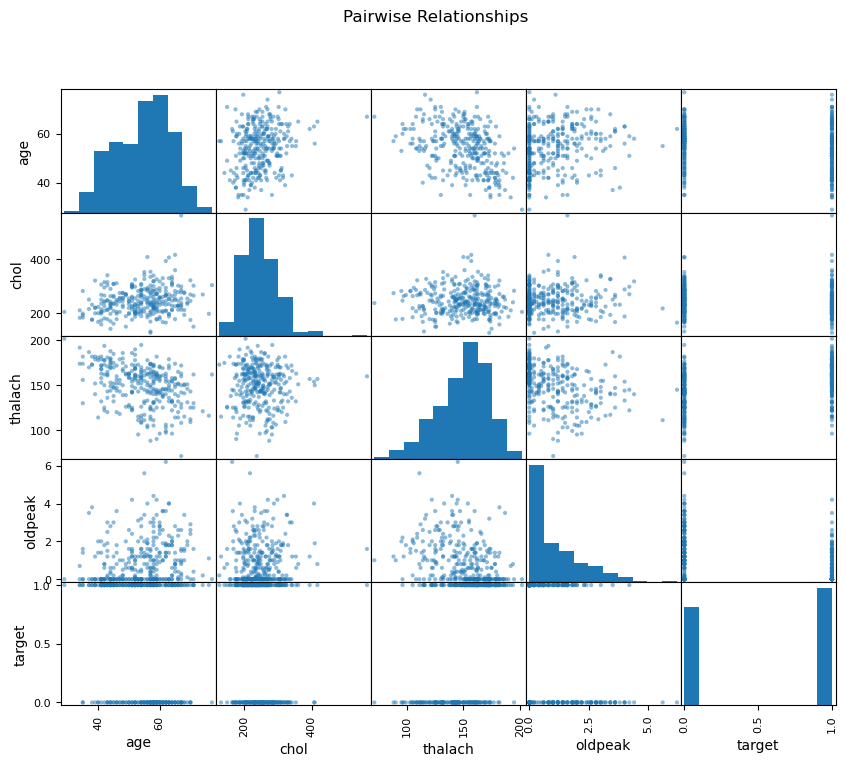


========== STRONGEST RELATIONSHIPS ==========

Top 5 Positive Correlations:

target   cp         0.433798
cp       target     0.433798
target   thalach    0.421741
thalach  target     0.421741
slope    thalach    0.386784
dtype: float64

Top 5 Negative Correlations:

oldpeak  target    -0.430696
target   exang     -0.436757
exang    target    -0.436757
slope    oldpeak   -0.577537
oldpeak  slope     -0.577537
dtype: float64

Project Completed Successfully ✅


In [ ]:
====================================================
# Full EDA + Correlation Analysis
# Heart Disease Dataset
# ===========# ===========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# -------------------------------
# 1. Load Dataset
# -------------------------------
df = pd.read_csv("heart.csv")

print("========== FIRST 5 ROWS ==========\n")
print(df.head())

print("\n========== DATASET INFO ==========\n")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========\n")
print(df.describe())

# -------------------------------
# 2. Missing Values Check
# -------------------------------
print("\n========== MISSING VALUES ==========\n")
print(df.isnull().sum())

# Drop missing values if any
df = df.dropna()

# -------------------------------
# 3. Distribution Analysis (Histograms)
# -------------------------------
print("\nGenerating Histograms...")

df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Outlier Detection (Boxplot)
# -------------------------------
print("\nGenerating Boxplot...")

plt.figure(figsize=(14,6))
plt.boxplot(df.values)
plt.xticks(range(1, len(df.columns)+1), df.columns, rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()

# -------------------------------
# 5. Correlation Analysis
# -------------------------------
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr(method='pearson')

print("\n========== CORRELATION MATRIX ==========\n")
print(correlation)

# Heatmap with Masked Upper Triangle + Annotation
plt.figure(figsize=(10,8))

mask = np.triu(np.ones_like(correlation, dtype=bool))
masked_corr = correlation.mask(mask)

heatmap = plt.imshow(masked_corr, cmap='coolwarm', interpolation='none')
plt.colorbar(heatmap)

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

# Annotate values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        if not mask[i, j]:
            plt.text(j, i,
                     f"{correlation.iloc[i, j]:.2f}",
                     ha='center',
                     va='center',
                     color='black')

plt.title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()

# -------------------------------
# 6. Pairwise Relationships (Scatter Matrix)
# -------------------------------
print("\nGenerating Scatter Matrix...\n")

selected_columns = ['age','chol','thalach','oldpeak','target']
scatter_matrix(df[selected_columns], figsize=(10,8))
plt.suptitle("Pairwise Relationships")
plt.show()

# -------------------------------
# 7. Strongest Positive & Negative Relationships
# -------------------------------
print("\n========== STRONGEST RELATIONSHIPS ==========\n")

corr_unstacked = correlation.unstack()
corr_unstacked = corr_unstacked.sort_values(ascending=False)

# Remove self correlations
corr_unstacked = corr_unstacked[corr_unstacked < 1]

print("Top 5 Positive Correlations:\n")
print(corr_unstacked.head(5))

print("\nTop 5 Negative Correlations:\n")
print(corr_unstacked.tail(5))

print("\nProject Completed Successfully ✅")